Step 1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply ggplot style
plt.style.use('ggplot')

# Optional: improve seaborn visuals
sns.set_theme()

Step 2 Load Dataset

In [2]:
data = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

In [3]:
# View first records
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


Step 3 Data Cleaning

In [4]:
# Remove leading/trailing spaces from column names
data.columns = data.columns.str.strip()

In [5]:
# Check columns 
print(data.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [6]:
# Rename columns for easier handling 
data.rename(columns={ 'Estimated Unemployment Rate (%)': 'Unemployment_Rate', 'Estimated Employed': 'Employed', 'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate', 'Region.1': 'Region_Group' }, inplace=True)

In [7]:
# Convert Date column to datetime 
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [8]:
# Check duplicates 
print("\nDuplicate Rows:", data.duplicated().sum())


Duplicate Rows: 0


In [9]:
data.describe

<bound method NDFrame.describe of              Region       Date Frequency  Unemployment_Rate  Employed  \
0    Andhra Pradesh 2020-01-31         M               5.48  16635535   
1    Andhra Pradesh 2020-02-29         M               5.83  16545652   
2    Andhra Pradesh 2020-03-31         M               5.79  15881197   
3    Andhra Pradesh 2020-04-30         M              20.51  11336911   
4    Andhra Pradesh 2020-05-31         M              17.43  12988845   
..              ...        ...       ...                ...       ...   
262     West Bengal 2020-06-30         M               7.29  30726310   
263     West Bengal 2020-07-31         M               6.83  35372506   
264     West Bengal 2020-08-31         M              14.87  33298644   
265     West Bengal 2020-09-30         M               9.35  35707239   
266     West Bengal 2020-10-31         M               9.98  33962549   

     Labour_Participation_Rate Region_Group  longitude  latitude  
0                     

Step 4 Feature Engineering

In [10]:
# Create Year and Month columns 
data['Year'] = data['Date'].dt.year  # Extract year from Date column
data['Month'] = data['Date'].dt.month  # Extract month number from Date column
data['Month_Name'] = data['Date'].dt.strftime('%B')  # Extract full month name from Date column

In [11]:
# Create Covid Period Variable 
data['Covid_Period'] = np.where( 
    data['Date'] >= '2020-03-01', 
    'During Covid', 
    'Before Covid' 
)

In [12]:
data.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region_Group,longitude,latitude,Year,Month,Month_Name,Covid_Period
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,2020,1,January,Before Covid
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2020,2,February,Before Covid
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,2020,3,March,During Covid
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,2020,4,April,During Covid
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,2020,5,May,During Covid


Step 5 Overall Unemployment Trend

In [13]:
monthly_unemployment = ( 
    data.groupby('Date')['Unemployment_Rate'] 
        .mean() .reset_index() 
)

<Axes: xlabel='Date', ylabel='Unemployment_Rate'>

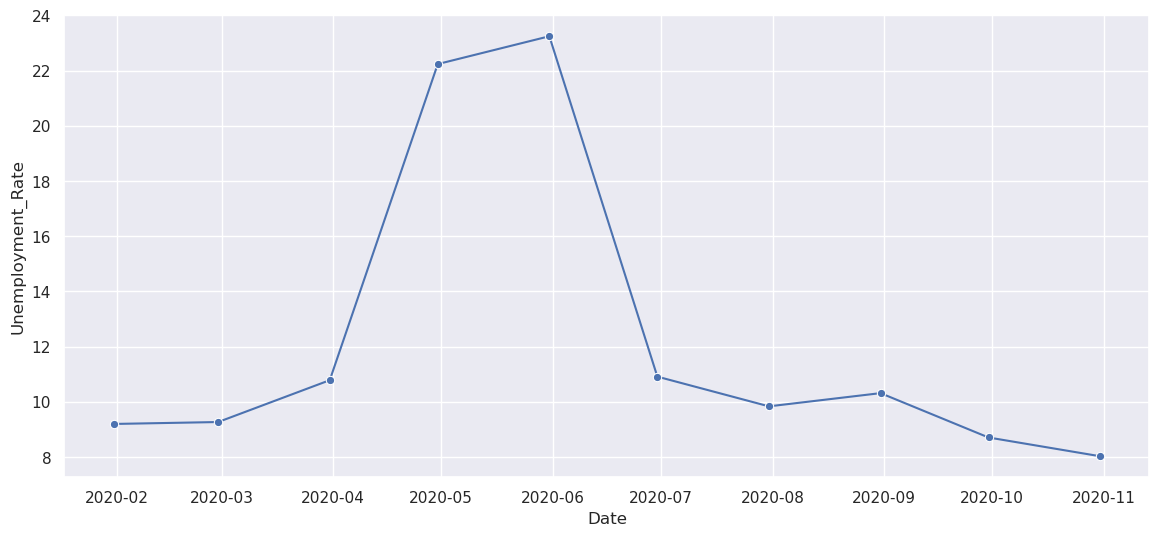

In [14]:
plt.figure(figsize=(14,6)) 
sns.lineplot( data=monthly_unemployment, 
              x='Date', y='Unemployment_Rate', 
              marker='o' 
            )

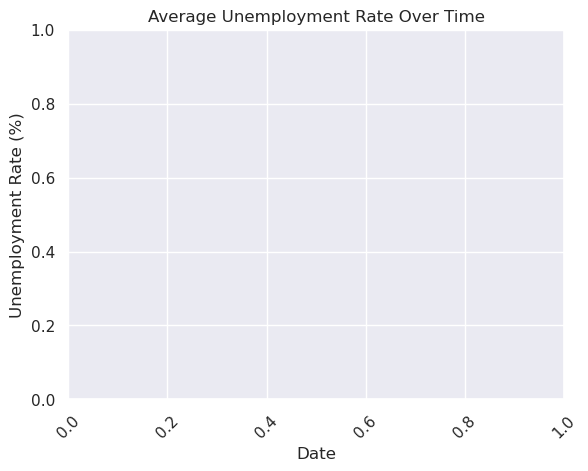

In [15]:
plt.title('Average Unemployment Rate Over Time') 
plt.xlabel('Date') 
plt.ylabel('Unemployment Rate (%)') 
plt.xticks(rotation=45) 
plt.show()

Step 6 Covid 19 Impact Analysis

In [16]:
covid_comparison = ( 
    data.groupby('Covid_Period')['Unemployment_Rate'] 
        .mean() 
        .reset_index()
)

In [17]:
print("\nAverage Unemployment Rate:") 
print(covid_comparison)


Average Unemployment Rate:
   Covid_Period  Unemployment_Rate
0  Before Covid           9.231346
1  During Covid          12.963860


<Axes: xlabel='Covid_Period', ylabel='Unemployment_Rate'>

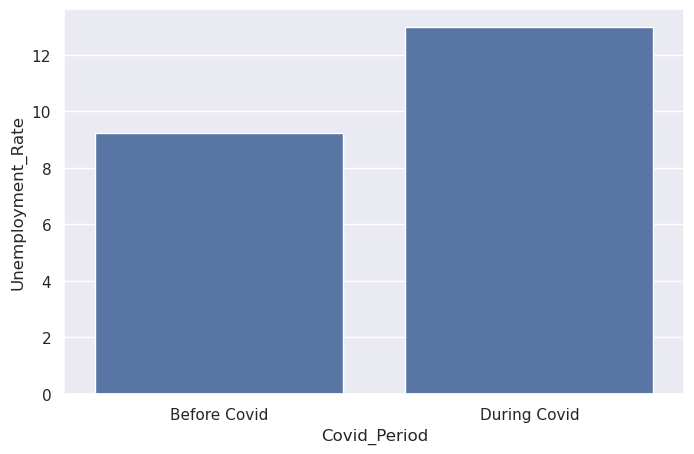

In [18]:
plt.figure(figsize=(8,5)) 
sns.barplot( 
    data=covid_comparison, 
    x='Covid_Period', 
    y='Unemployment_Rate' 
)

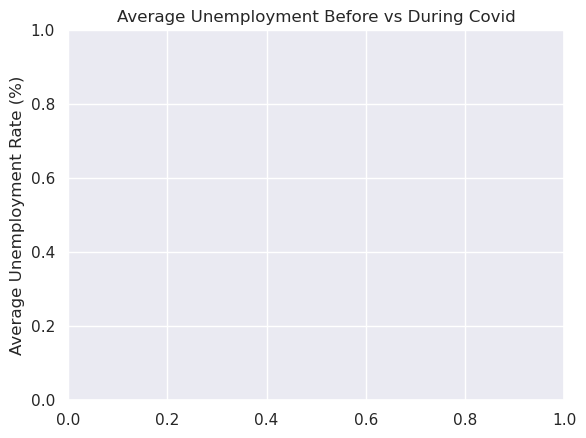

In [19]:
plt.title('Average Unemployment Before vs During Covid') 
plt.ylabel('Average Unemployment Rate (%)') 
plt.show()

Step 7 Monthly Covid Effect

In [20]:
plt.figure(figsize=(14,6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Axes: xlabel='Date', ylabel='Unemployment_Rate'>

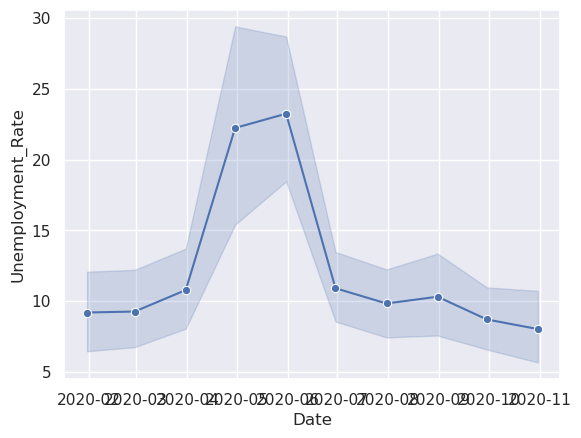

In [21]:
sns.lineplot( 
    data=data, x='Date', 
    y='Unemployment_Rate', 
    estimator='mean', 
    marker='o' 
)

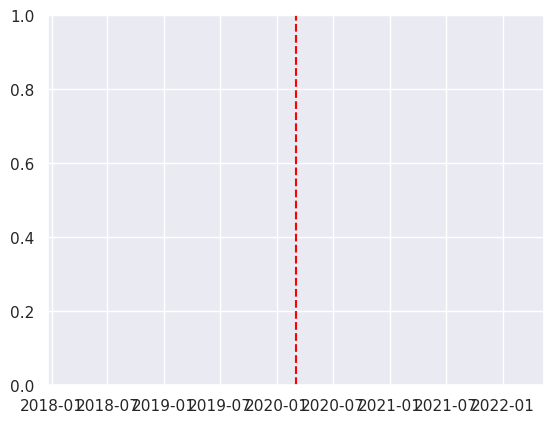

In [22]:
plt.axvline( 
    pd.to_datetime('2020-03-01'), 
    color='red', 
    linestyle='--', 
    label='Covid Start' 
)

/tmp/ipykernel_2741/3555620789.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


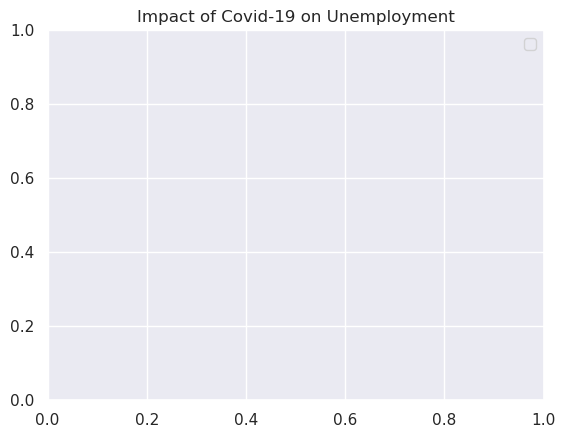

In [23]:
plt.legend() 
plt.title('Impact of Covid-19 on Unemployment') 
plt.show()

Step 8 Regional Analysis

In [24]:
region_avg = ( 
    data.groupby('Region')['Unemployment_Rate'] 
        .mean() 
        .sort_values(ascending=False) 
)

<Axes: xlabel='Region'>

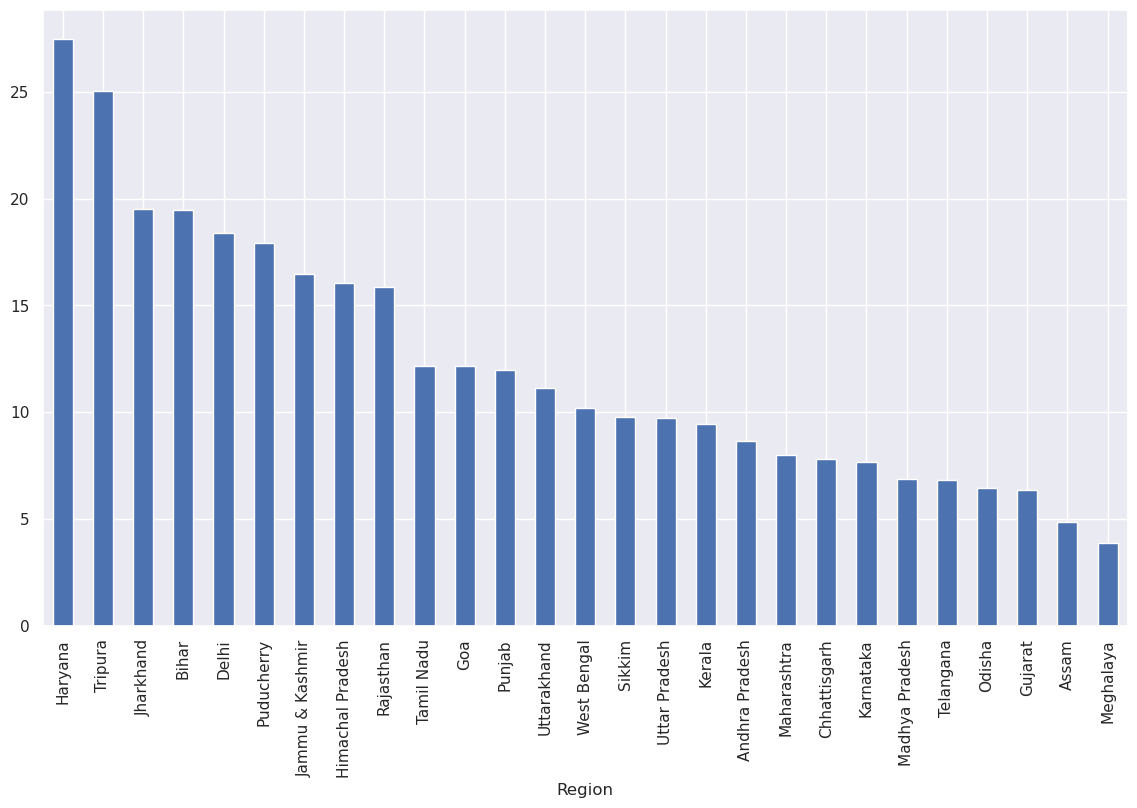

In [25]:
plt.figure(figsize=(14,8)) 
region_avg.plot(kind='bar')

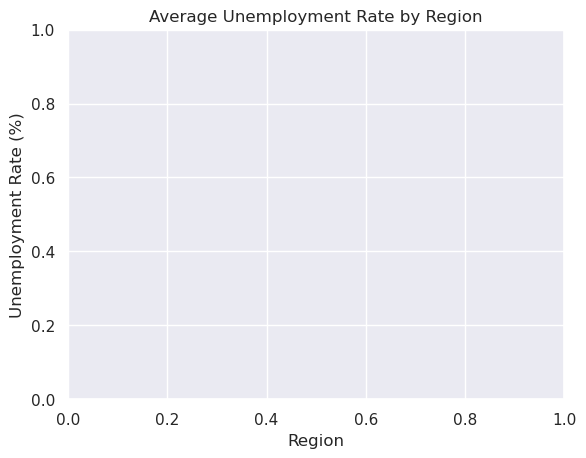

In [26]:
plt.title('Average Unemployment Rate by Region') 
plt.ylabel('Unemployment Rate (%)') 
plt.xlabel('Region') 
plt.show()

In [27]:
print("\nTop 10 Regions with Highest Unemployment") 
print(region_avg.head(10))


Top 10 Regions with Highest Unemployment
Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Unemployment_Rate, dtype: float64


Step 9 Geographical Region Group Analysis

In [28]:
group_avg = ( data.groupby('Region_Group')['Unemployment_Rate'] 
    .mean() 
    .sort_values(ascending=False) )

<Axes: xlabel='Region_Group'>

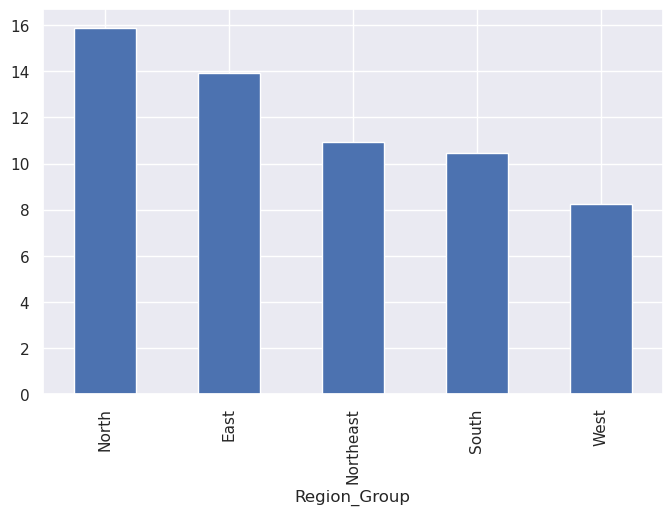

In [29]:
plt.figure(figsize=(8,5)) 
group_avg.plot(kind='bar')

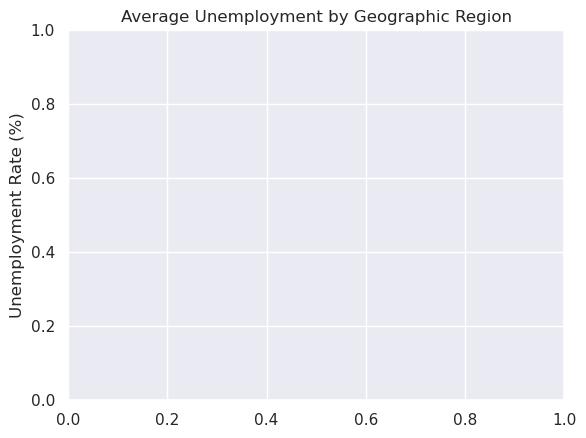

In [30]:
plt.title('Average Unemployment by Geographic Region') 
plt.ylabel('Unemployment Rate (%)') 
plt.show()

Step 10 Employment vs Unemployment

In [31]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Employed', ylabel='Unemployment_Rate'>

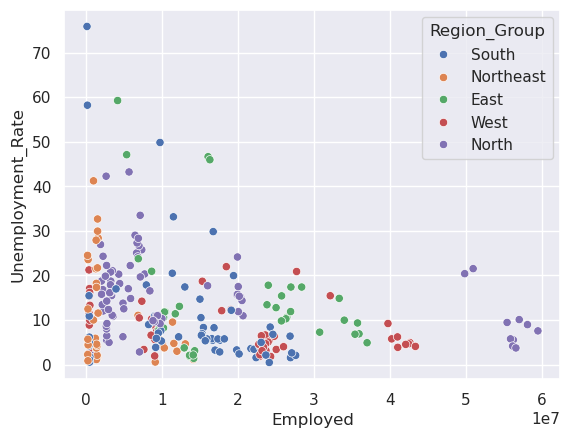

In [32]:
sns.scatterplot( 
    data=data, 
    x='Employed', 
    y='Unemployment_Rate', 
    hue='Region_Group' 
)

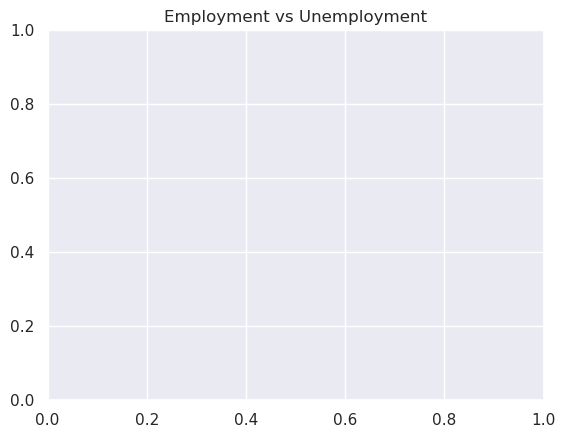

In [33]:
plt.title('Employment vs Unemployment') 
plt.show()

Step 11 Labour Participation Analysis

In [34]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Labour_Participation_Rate', ylabel='Unemployment_Rate'>

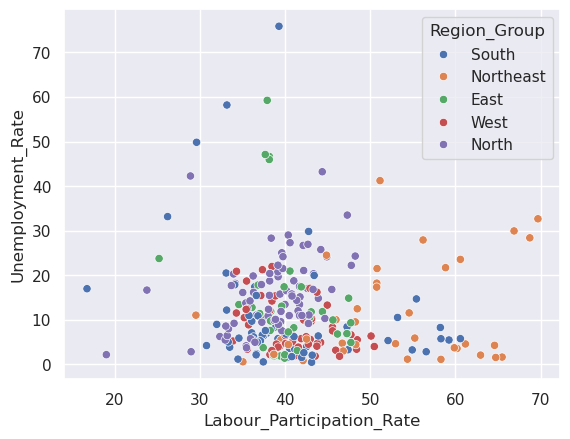

In [35]:
sns.scatterplot(
    data=data, 
    x='Labour_Participation_Rate', 
    y='Unemployment_Rate', 
    hue='Region_Group' )

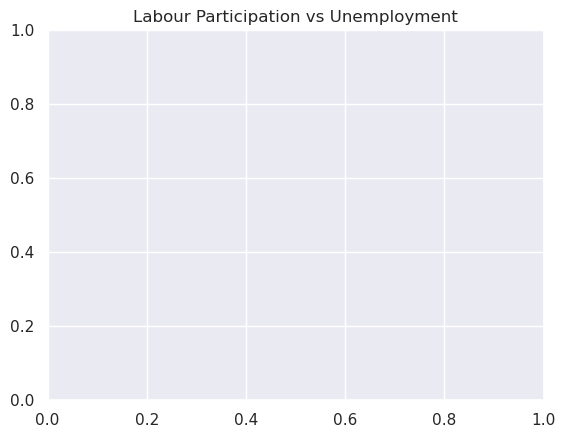

In [36]:
plt.title('Labour Participation vs Unemployment') 
plt.show()

Step 12 Correlation Analysis

   Unemployment_Rate  Employed  Labour_Participation_Rate  longitude  \
0               5.48  16635535                      41.02    15.9129   
1               5.83  16545652                      40.90    15.9129   
2               5.79  15881197                      39.18    15.9129   
3              20.51  11336911                      33.10    15.9129   
4              17.43  12988845                      36.46    15.9129   

   latitude  Year  Month  
0     79.74  2020      1  
1     79.74  2020      2  
2     79.74  2020      3  
3     79.74  2020      4  
4     79.74  2020      5  
(267, 7)
                           Unemployment_Rate  Employed  \
Unemployment_Rate                   1.000000 -0.245176   
Employed                           -0.245176  1.000000   
Labour_Participation_Rate          -0.073540 -0.047948   
longitude                           0.149976 -0.113664   
latitude                           -0.023976 -0.119321   
Year                                     NaN    

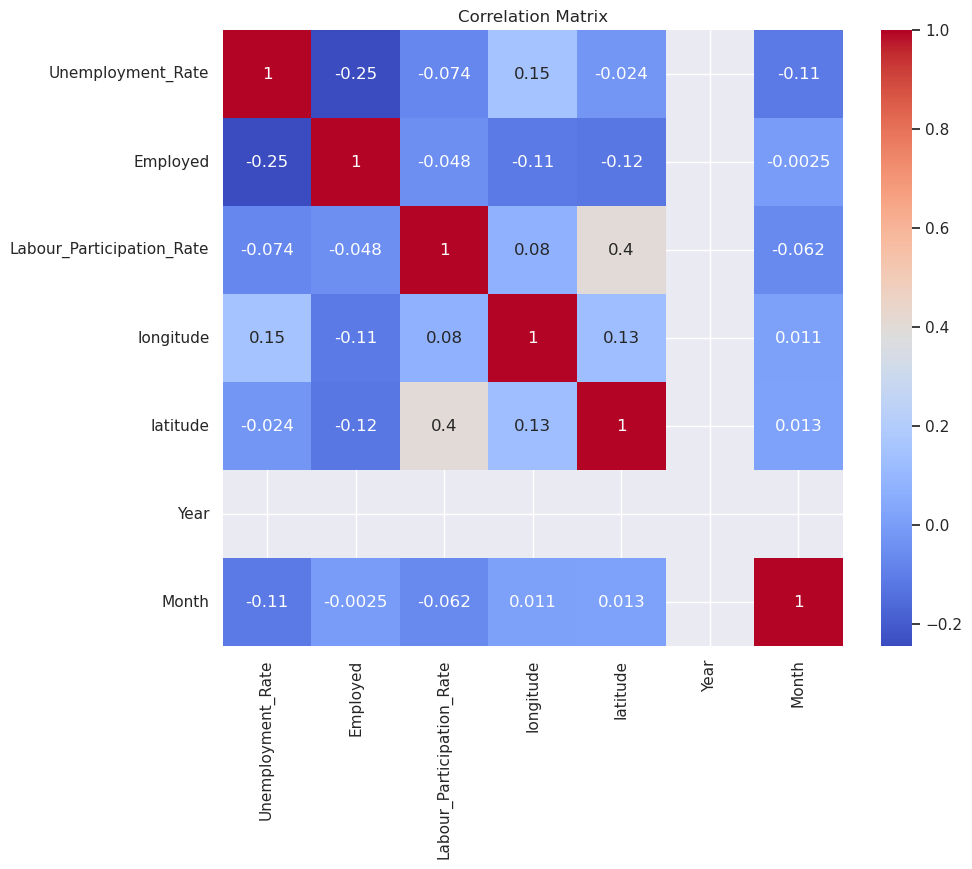

In [43]:
numeric_data = data.select_dtypes(include=['number'])

print(numeric_data.head())
print(numeric_data.shape)

corr_matrix = numeric_data.corr()
print(corr_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Step 13 Top Regions Most Affected by Covid

In [ ]:
covid_region = ( 
    data.groupby('Region')['Unemployment_Rate'] 
        .max() 
        .sort_values(ascending=False) 
        .head(15) )

In [ ]:
plt.figure(figsize=(12,7)) 
covid_region.plot(kind='bar')

In [ ]:
plt.title('Regions Most Affected During Covid') 
plt.ylabel('Peak Unemployment Rate (%)') 
plt.show()

Step 15 Unemployment Distribution

In [ ]:
plt.figure(figsize=(10,6))

In [ ]:
sns.histplot( 
    data['Unemployment_Rate'], 
    bins=20, kde=True )

In [ ]:
plt.title('Distribution of Unemployment Rate') 
plt.show()

Step 16 Boxplot for outliners

In [ ]:
plt.figure(figsize=(8,5))

In [ ]:
sns.boxplot( y=data['Unemployment_Rate'] )

In [ ]:
plt.title('Outlier Detection') 
plt.show()

In [ ]:
print("\n================ INSIGHTS ================")

In [ ]:
print(""" 
1. Examine whether unemployment increased sharply after March 2020. 
2. Identify regions with the highest average unemployment. 
3. Determine which geographical zones were most affected. 
4. Investigate the relationship between employment and unemployment. 
5. Analyze seasonal patterns in unemployment rates. 
6. Compare unemployment levels before and during Covid. 
7. Identify regions with extreme unemployment spikes. 
8. Use findings to recommend targeted employment programs, economic recovery plans, 
and workforce development initiatives. """)